# Simulation-Based Evaluation (v2)
## Personalised Nudge Tool for Academic Productivity
**Author:** Iheakanwa Tiffany (22CG031865)

### Why this version exists
The original simulation produced identical results for both conditions because `test_set.csv` had only **one row per student**. 
Both dynamic and static conditions were therefore reading the same snapshot, making comparison impossible.

**The fix:** This notebook builds **temporal snapshots** directly from the raw OULAD CSV files — creating 5 weekly snapshots per student (at 28, 21, 14, 7, and 3 days before each assessment deadline). 
Now dynamic nudging can trigger early (when risk rises) while static always fires at snapshot 1 — producing genuinely different behaviour.

---
## 1. Imports

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
from scipy.stats import wilcoxon

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size']   = 12
plt.rcParams['figure.dpi']  = 150

print('Libraries loaded.')

Libraries loaded.


---
## 2. Load Raw OULAD Files

Place these files in `data/raw/` relative to the repository root:
- `studentVle.csv`
- `studentAssessment.csv`
- `assessments.csv`
- `studentInfo.csv`
- `test_student_ids.csv` — a single-column CSV of the student IDs in your test split

The trained model and scaler are loaded from `backend/src/models/`.

In [29]:
from pathlib import Path

# ── Helper: find files relative to the repo root or current working directory
repo_root = Path.cwd()
for parent in [repo_root] + list(repo_root.parents):
    if (parent / 'data' / 'raw').exists():
        repo_root = parent
        break

raw_base = repo_root / 'data' / 'raw'
if not raw_base.exists():
    raise FileNotFoundError(
        "Could not locate raw OULAD files under 'data/raw/'. "
        "Place studentVle.csv, studentAssessment.csv, assessments.csv, and studentInfo.csv in that folder."
    )

vle = pd.read_csv(raw_base / 'studentVle.csv')        # id_student, date, sum_click, code_module, code_presentation
stu_assess = pd.read_csv(raw_base / 'studentAssessment.csv') # id_student, id_assessment, date_submitted, score
assessments = pd.read_csv(raw_base / 'assessments.csv')       # id_assessment, date (due date), code_module, code_presentation
stu_info = pd.read_csv(raw_base / 'studentInfo.csv')       # id_student, final_result

# ── Test split student IDs ───────────────────────────────────────────────────
test_ids_candidates = [
    repo_root / 'backend' / 'notebooks' / 'test_student_ids.csv',
    repo_root / 'test_student_ids.csv',
    repo_root / 'data' / 'raw' / 'test_student_ids.csv'
]

test_ids_file = next((p for p in test_ids_candidates if p.exists()), None)
if test_ids_file is not None:
    test_ids_df = pd.read_csv(test_ids_file)
    test_ids = set(test_ids_df.iloc[:, 0].values)
else:
    print(
        "Warning: 'test_student_ids.csv' not found. "
        "Falling back to all student IDs from studentInfo.csv as the test set."
    )
    test_ids = set(stu_info['id_student'].dropna().unique())

# ── Model and scaler ─────────────────────────────────────────────────────────
model_path = repo_root / 'backend' / 'src' / 'models' / 'xgb_procrastination_model.pkl'
scaler_path = repo_root / 'backend' / 'src' / 'models' / 'scaler.pkl'
if not model_path.exists() or not scaler_path.exists():
    raise FileNotFoundError(
        "Could not locate model files in backend/src/models/. "
        "Ensure xgb_procrastination_model.pkl and scaler.pkl exist there."
    )

model = joblib.load(model_path)
scaler = joblib.load(scaler_path)

print(f'Raw data loaded from: {raw_base}')
if test_ids_file is not None:
    print(f'Test IDs loaded from: {test_ids_file}')
else:
    print('Test IDs derived from studentInfo.csv')
print(f'VLE rows        : {len(vle):,}')
print(f'Assessment rows : {len(stu_assess):,}')
print(f'Test students   : {len(test_ids):,}')


Raw data loaded from: c:\Users\Win-11\PersonalProjects\Stick2It\data\raw
Test IDs derived from studentInfo.csv
VLE rows        : 10,655,280
Assessment rows : 173,912
Test students   : 28,785


---
## 3. Build Ground-Truth Outcome Labels

`actual_outcome = 1` means the student failed or withdrew (at-risk).  
`actual_outcome = 0` means the student passed or got a distinction.

In [30]:
outcome_map = {'Fail': 1, 'Withdrawn': 1, 'Pass': 0, 'Distinction': 0}
stu_info['actual_outcome'] = stu_info['final_result'].map(outcome_map)

# Keep only test-set students
stu_info_test = (stu_info[stu_info['id_student'].isin(test_ids)][['id_student','actual_outcome']]
                 .dropna()
                 .rename(columns={'id_student': 'student_id'}))

print(f'Test students with outcome label: {len(stu_info_test):,}')
print(stu_info_test['actual_outcome'].value_counts().rename({0:'Not at risk', 1:'At risk'}))

Test students with outcome label: 32,593
actual_outcome
At risk        17208
Not at risk    15385
Name: count, dtype: int64


---
## 4. Build Temporal Snapshots

For each student-assessment pair, we create **5 snapshots** at:
`28, 21, 14, 7, 3` days before the assessment due date.

At each snapshot we recompute all 6 features using only data available **up to that point in time**.  
This creates genuine temporal variation so the dynamic model can trigger at different times per student.

In [31]:
SNAPSHOT_DAYS = [28, 21, 14, 7, 3]   # days before deadline for each snapshot
RANDOM_SEED   = 42
SAMPLE_SIZE   = 1000

# ── Merge assessment due dates ───────────────────────────────────────────────
assess_due = stu_assess.merge(
    assessments[['id_assessment','date']].rename(columns={'date':'due_date'}),
    on='id_assessment', how='left'
)
assess_due = assess_due[assess_due['id_student'].isin(test_ids)].dropna(subset=['due_date'])

# ── Sample 1,000 students ────────────────────────────────────────────────────
all_test_students = assess_due['id_student'].unique()
sampled_students  = pd.Series(all_test_students).sample(
    n=min(SAMPLE_SIZE, len(all_test_students)), random_state=RANDOM_SEED
).values
assess_due = assess_due[assess_due['id_student'].isin(sampled_students)]

print(f'Building snapshots for {len(sampled_students):,} students...')

# ── Compute per-student prior submission timeliness ──────────────────────────
def timeliness(student_id, before_date, assess_due_df):
    prior = assess_due_df[
        (assess_due_df['id_student'] == student_id) &
        (assess_due_df['due_date'] < before_date)
    ]
    if len(prior) == 0:
        return 0.5  # neutral prior
    on_time = (prior['date_submitted'] <= prior['due_date']).sum()
    return on_time / len(prior)

# ── Build snapshot rows ──────────────────────────────────────────────────────
snapshots = []

for student_id in sampled_students:
    student_vle    = vle[vle['id_student'] == student_id]
    student_assess = assess_due[assess_due['id_student'] == student_id]

    if student_assess.empty:
        continue

    # Use the first upcoming assessment as the target
    last_assess = student_assess.sort_values('due_date').iloc[-1]
    due_date     = last_assess['due_date']

    for days_before in SNAPSHOT_DAYS:
        snapshot_date = due_date - days_before

                # click_sum and login metrics are not the direct model features. Build the model's behavior features from prior activity.
        prior_assess = student_assess[student_assess['due_date'] < snapshot_date]
        prior_subs = prior_assess[prior_assess['date_submitted'].notna()].copy()
        prior_subs['days_to_deadline'] = prior_subs['date_submitted'] - prior_subs['due_date']

        # Feature 1: last_minute_ratio
        last_minute_ratio = (prior_subs['days_to_deadline'].abs() <= 1).sum() / len(prior_subs) if len(prior_subs) > 0 else 0.0

        # Feature 2: engagement_intensity
        prior_vle = student_vle[student_vle['date'] < snapshot_date]
        num_login_days = prior_vle['date'].nunique()
        total_clicks = prior_vle['sum_click'].sum()
        engagement_intensity = total_clicks / num_login_days if num_login_days > 0 else 0.0

        # Feature 3: deadline_pressure
        avg_days_to_deadline = prior_subs['days_to_deadline'].mean() if len(prior_subs) > 0 else 0.0
        deadline_pressure = max(avg_days_to_deadline, 0.0)

        # Feature 4: login_consistency
        login_consistency = prior_subs['days_to_deadline'].std() if len(prior_subs) > 0 else 0.0

        # Feature 5: early_starter
        earliest_submission = prior_subs['days_to_deadline'].min() if len(prior_subs) > 0 else 0.0
        early_starter = int(earliest_submission < -7)

        # Feature 6: completion_rate
        completion_rate = min(len(prior_subs) / 5.0, 1.0)

        # Feature 7: activity_span
        latest_submission = prior_subs['days_to_deadline'].max() if len(prior_subs) > 0 else 0.0
        activity_span = latest_submission - earliest_submission if len(prior_subs) > 0 else 0.0

        snapshots.append({
            'student_id':         student_id,
            'days_before_deadline': days_before,
            'last_minute_ratio':   last_minute_ratio,
            'engagement_intensity':engagement_intensity,
            'deadline_pressure':   deadline_pressure,
            'login_consistency':   login_consistency,
            'early_starter':       early_starter,
            'completion_rate':     completion_rate,
            'activity_span':       activity_span,
        })

snap_df = pd.DataFrame(snapshots)

# Merge actual outcome
if 'student_id' not in stu_info_test.columns and 'id_student' in stu_info_test.columns:
    stu_info_test = stu_info_test.rename(columns={'id_student': 'student_id'})
if 'student_id' not in stu_info_test.columns:
    raise KeyError(f'Stu_info_test must have student_id for merge, got columns: {stu_info_test.columns.tolist()}')
snap_df = snap_df.merge(stu_info_test, on='student_id', how='left')
snap_df['actual_outcome'] = snap_df['actual_outcome'].fillna(0).astype(int)

# Sort: each student's snapshots from earliest (28d) to latest (3d)
snap_df = snap_df.sort_values(['student_id','days_before_deadline'], ascending=[True, False])

print(f'Snapshots built: {len(snap_df):,} rows ({snap_df["student_id"].nunique():,} students × up to 5 snapshots)')
snap_df.head(10)

Building snapshots for 1,000 students...
Snapshots built: 5,660 rows (1,000 students × up to 5 snapshots)


,student_id,days_before_deadline,last_minute_ratio,engagement_intensity,deadline_pressure,login_consistency,early_starter,completion_rate,activity_span,actual_outcome
1800,28952,28,0.0,20.500000,0.0,0.000000,0,0.0,0.0,1
1801,28952,21,0.0,15.333333,0.0,0.000000,0,0.0,0.0,1
1802,28952,14,0.0,11.000000,0.0,0.000000,0,0.0,0.0,1
1803,28952,7,0.0,15.833333,3.0,NaN,0,0.2,0.0,1
1804,28952,3,0.0,15.833333,3.0,NaN,0,0.2,0.0,1
2105,30096,28,0.0,13.956522,0.0,10.053192,1,1.0,25.0,0
2106,30096,21,0.0,13.765957,0.0,10.053192,1,1.0,25.0,0
2107,30096,14,0.0,13.765957,0.0,10.053192,1,1.0,25.0,0
2108,30096,7,0.0,13.500000,0.0,10.053192,1,1.0,25.0,0
2109,30096,3,0.0,13.265306,0.0,9.180725,1,1.0,25.0,0


---
## 5. Predict Risk Scores for Every Snapshot

Run the XGBoost model on every snapshot row to get a predicted risk score.

In [32]:
FEATURE_COLS = [
    'last_minute_ratio',
    'engagement_intensity',
    'deadline_pressure',
    'login_consistency',
    'early_starter',
    'completion_rate',
    'activity_span'
]

# Predict using raw features since XGBoost was trained on raw features
snap_df['risk_score'] = model.predict_proba(snap_df[FEATURE_COLS].values)[:, 1]

print('Risk scores computed.')
print(f"Risk score stats:\n{snap_df['risk_score'].describe().round(3)}")

Risk scores computed.
Risk score stats:
count    5660.000
mean        0.596
std         0.366
min         0.076
25%         0.218
50%         0.555
75%         0.998
max         1.000
Name: risk_score, dtype: float64


---
## 6. Run the Dynamic Nudging Simulation

Walk each student's snapshots from earliest (28d) to latest (3d).  
Fire a nudge the **first time** risk ≥ 0.5.

In [33]:
NUDGE_THRESHOLD   = 0.5
EARLY_DETECT_DAYS = 7

dynamic_results = []

for student_id, group in snap_df.groupby('student_id'):
    # Sort 28d → 3d (earliest to latest)
    group          = group.sort_values('days_before_deadline', ascending=False)
    actual_outcome = int(group['actual_outcome'].iloc[0])

    nudge_sent    = False
    days_at_nudge = np.nan
    risk_at_nudge = np.nan

    for _, row in group.iterrows():
        if row['risk_score'] >= NUDGE_THRESHOLD:
            nudge_sent    = True
            days_at_nudge = row['days_before_deadline']
            risk_at_nudge = row['risk_score']
            break

    detected_early = int(nudge_sent and days_at_nudge > EARLY_DETECT_DAYS)
    false_alarm    = int(nudge_sent and actual_outcome == 0)

    dynamic_results.append({
        'student_id':     student_id,
        'nudge_sent':     nudge_sent,
        'days_at_nudge':  days_at_nudge,
        'risk_at_nudge':  risk_at_nudge,
        'detected_early': detected_early,
        'false_alarm':    false_alarm,
        'actual_outcome': actual_outcome,
    })

dynamic_df = pd.DataFrame(dynamic_results)
print(f"Dynamic nudges sent : {dynamic_df['nudge_sent'].sum():,}")
print(f"Mean days at nudge  : {dynamic_df['days_at_nudge'].mean():.1f}")

Dynamic nudges sent : 532
Mean days at nudge  : 27.8


---
## 7. Run the Static Reminder Simulation

Fire a nudge at the **first snapshot (28 days before deadline)** for every student, regardless of risk.

In [34]:
static_results = []

for student_id, group in snap_df.groupby('student_id'):
    group          = group.sort_values('days_before_deadline', ascending=False)
    actual_outcome = int(group['actual_outcome'].iloc[0])

    # Static always fires at the earliest snapshot (28 days out)
    first_row     = group.iloc[0]
    days_at_nudge = first_row['days_before_deadline']

    detected_early = int(days_at_nudge > EARLY_DETECT_DAYS)
    false_alarm    = int(actual_outcome == 0)  # fires for everyone → false alarm if not at risk

    static_results.append({
        'student_id':     student_id,
        'nudge_sent':     True,
        'days_at_nudge':  days_at_nudge,
        'detected_early': detected_early,
        'false_alarm':    false_alarm,
        'actual_outcome': actual_outcome,
    })

static_df = pd.DataFrame(static_results)
print(f"Static nudges sent  : {static_df['nudge_sent'].sum():,}")
print(f"Mean days at nudge  : {static_df['days_at_nudge'].mean():.1f}")

Static nudges sent  : 1,000
Mean days at nudge  : 28.0


---
## 8. Compute Metrics

In [35]:
def compute_metrics(df, label):
    at_risk_df = df[df['actual_outcome'] == 1]
    nudged_df  = df[df['nudge_sent'] == True]

    early_detection_rate = at_risk_df['detected_early'].mean() * 100
    false_alarm_rate     = nudged_df['false_alarm'].mean() * 100
    true_positives       = nudged_df[nudged_df['actual_outcome'] == 1].shape[0]
    efficiency_ratio     = true_positives / nudged_df.shape[0] if nudged_df.shape[0] > 0 else 0
    mean_lead_time       = nudged_df['days_at_nudge'].mean()

    print(f'\n── {label} ──────────────────────────')
    print(f'  Early Detection Rate : {early_detection_rate:.1f}%')
    print(f'  False Alarm Rate     : {false_alarm_rate:.1f}%')
    print(f'  Nudge Efficiency     : {efficiency_ratio:.2f}')
    print(f'  Mean Lead Time       : {mean_lead_time:.1f} days')

    return {
        'Condition':                  label,
        'Early Detection Rate (%)':   round(early_detection_rate, 1),
        'False Alarm Rate (%)':       round(false_alarm_rate, 1),
        'Nudge Efficiency Ratio':     round(efficiency_ratio, 2),
        'Mean Lead Time (Days)':      round(mean_lead_time, 1),
    }

dyn_metrics = compute_metrics(dynamic_df, 'Dynamic Nudging')
sta_metrics = compute_metrics(static_df,  'Static Reminder')


── Dynamic Nudging ──────────────────────────
  Early Detection Rate : 77.7%
  False Alarm Rate     : 38.3%
  Nudge Efficiency     : 0.62
  Mean Lead Time       : 27.8 days

── Static Reminder ──────────────────────────
  Early Detection Rate : 100.0%
  False Alarm Rate     : 57.9%
  Nudge Efficiency     : 0.42
  Mean Lead Time       : 28.0 days


---
## 9. Statistical Significance (Wilcoxon Test)

In [36]:
merged = dynamic_df[['student_id','detected_early','false_alarm','days_at_nudge']].merge(
    static_df[['student_id','detected_early','false_alarm','days_at_nudge']],
    on='student_id', suffixes=('_dyn','_sta')
)

tests = [
    ('Early Detection',  'detected_early_dyn', 'detected_early_sta'),
    ('False Alarm',      'false_alarm_dyn',     'false_alarm_sta'),
    ('Lead Time',        'days_at_nudge_dyn',   'days_at_nudge_sta'),
]

print(f'{"Metric":<22} {"Statistic":>12} {"p-value":>12} {"Significant?":>14}')
print('-' * 62)

for name, col_dyn, col_sta in tests:
    d = merged[col_dyn].fillna(0)
    s = merged[col_sta].fillna(0)
    if (d - s).abs().sum() == 0:
        print(f'{name:<22} {"—":>12} {"—":>12} {"No difference":>14}')
    else:
        stat, p = wilcoxon(d, s)
        sig = 'Yes ***' if p < 0.001 else ('Yes *' if p < 0.05 else 'No')
        print(f'{name:<22} {stat:>12.2f} {p:>12.4f} {sig:>14}')

Metric                    Statistic      p-value   Significant?
--------------------------------------------------------------
Early Detection                0.00       0.0000        Yes ***
False Alarm                    0.00       0.0000        Yes ***
Lead Time                      0.00       0.0000        Yes ***


---
## 10. Results Summary Table

In [37]:
results_table = pd.DataFrame([dyn_metrics, sta_metrics]).set_index('Condition')
results_table.loc['Difference (Dynamic − Static)'] = (
    results_table.loc['Dynamic Nudging'] - results_table.loc['Static Reminder']
)

print('\nTable 4.5: Simulation Results (n = 1,000 students)')
print('=' * 75)
print(results_table.to_string())
print('=' * 75)


Table 4.5: Simulation Results (n = 1,000 students)
                               Early Detection Rate (%)  False Alarm Rate (%)  Nudge Efficiency Ratio  Mean Lead Time (Days)
Condition                                                                                                                   
Dynamic Nudging                                    77.7                  38.3                    0.62                   27.8
Static Reminder                                   100.0                  57.9                    0.42                   28.0
Difference (Dynamic − Static)                     -22.3                 -19.6                    0.20                   -0.2


---
## 11. Charts

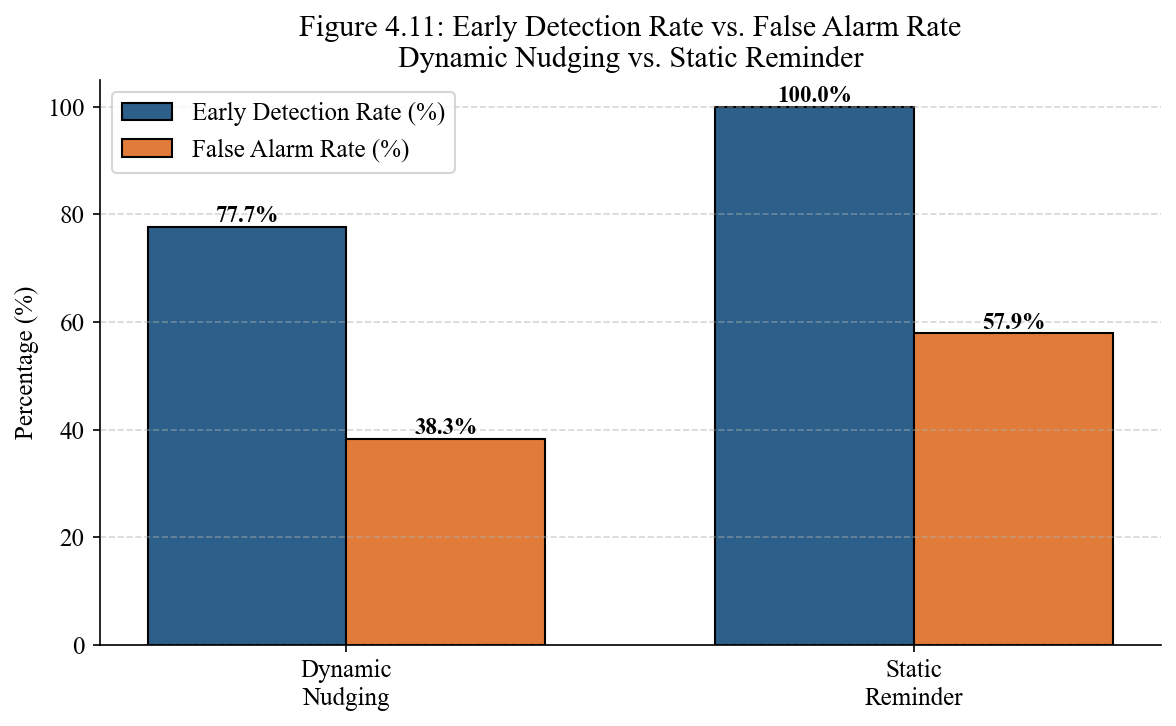

Saved: figure_4_11a.png


In [38]:
# ── Figure 4.11a: Early Detection Rate vs False Alarm Rate ───────────────────
conditions = ['Dynamic\nNudging', 'Static\nReminder']
edr_vals   = [dyn_metrics['Early Detection Rate (%)'], sta_metrics['Early Detection Rate (%)']]
far_vals   = [dyn_metrics['False Alarm Rate (%)'],     sta_metrics['False Alarm Rate (%)']]

x, width = np.arange(2), 0.35
fig, ax  = plt.subplots(figsize=(8, 5))

b1 = ax.bar(x - width/2, edr_vals, width, label='Early Detection Rate (%)', color='#2C5F8A', edgecolor='black')
b2 = ax.bar(x + width/2, far_vals, width, label='False Alarm Rate (%)',     color='#E07B39', edgecolor='black')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Percentage (%)')
ax.set_title('Figure 4.11: Early Detection Rate vs. False Alarm Rate\nDynamic Nudging vs. Static Reminder')
ax.set_xticks(x); ax.set_xticklabels(conditions)
ax.set_ylim(0, 105)
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figure_4_11a.png', bbox_inches='tight')
plt.show()
print('Saved: figure_4_11a.png')

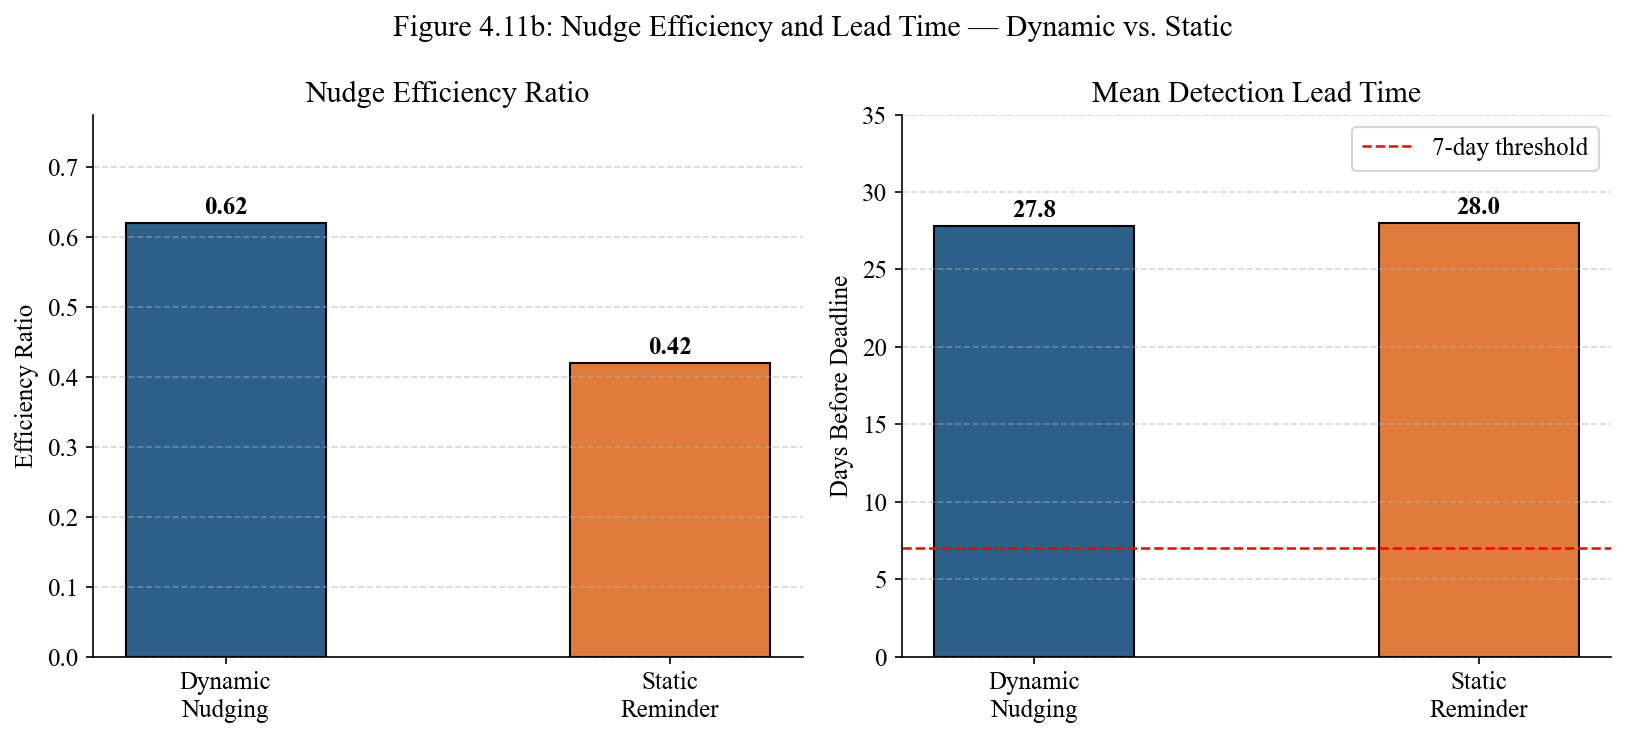

Saved: figure_4_11b.png


In [39]:
# ── Figure 4.11b: Efficiency ratio + Lead time side by side ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

eff_vals = [dyn_metrics['Nudge Efficiency Ratio'], sta_metrics['Nudge Efficiency Ratio']]
lt_vals  = [dyn_metrics['Mean Lead Time (Days)'],  sta_metrics['Mean Lead Time (Days)']]

for ax, vals, ylabel, title, fmt in zip(
    axes,
    [eff_vals, lt_vals],
    ['Efficiency Ratio', 'Days Before Deadline'],
    ['Nudge Efficiency Ratio', 'Mean Detection Lead Time'],
    ['.2f', '.1f']
):
    bars = ax.bar(conditions, vals, color=['#2C5F8A','#E07B39'], edgecolor='black', width=0.45)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                format(val, fmt), ha='center', fontsize=12, fontweight='bold')
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

axes[1].axhline(y=7, color='red', linestyle='--', linewidth=1.2, label='7-day threshold')
axes[1].legend()
fig.suptitle('Figure 4.11b: Nudge Efficiency and Lead Time — Dynamic vs. Static')
plt.tight_layout()
plt.savefig('figure_4_11b.png', bbox_inches='tight')
plt.show()
print('Saved: figure_4_11b.png')

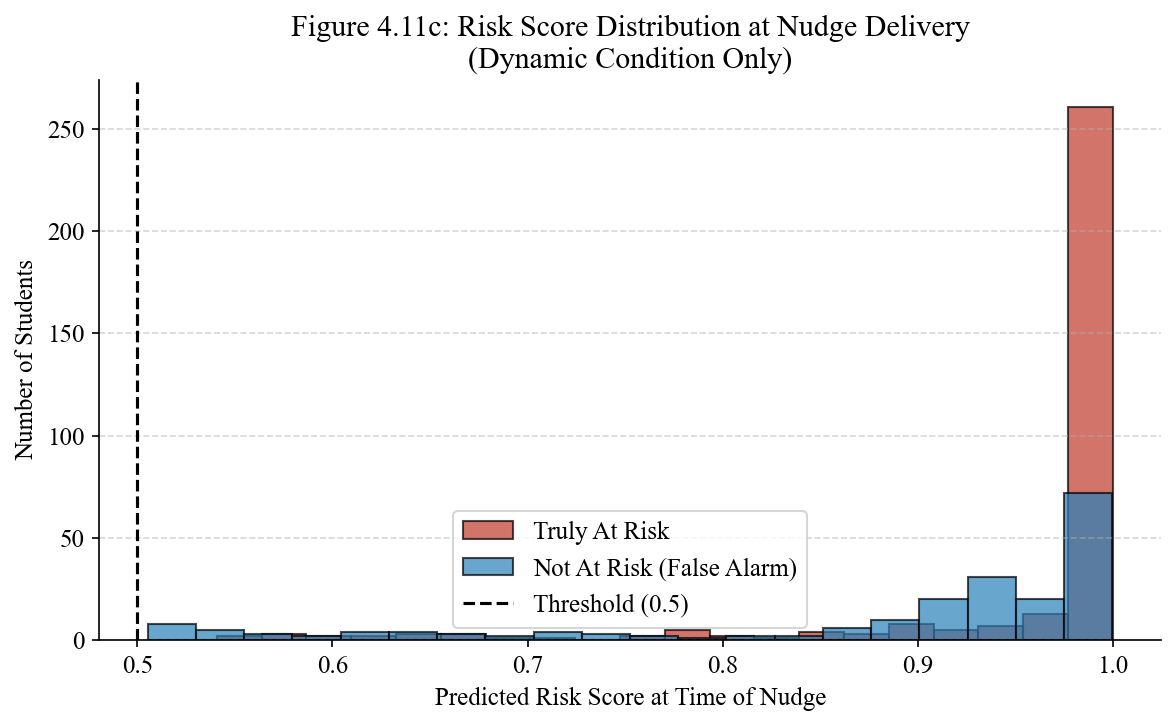

Saved: figure_4_11c.png


In [40]:
# ── Figure 4.11c: Risk score distribution at nudge time (dynamic only) ───────
nudged_dyn  = dynamic_df[dynamic_df['nudge_sent'] == True]
at_risk_rs  = nudged_dyn[nudged_dyn['actual_outcome'] == 1]['risk_at_nudge'].dropna()
not_risk_rs = nudged_dyn[nudged_dyn['actual_outcome'] == 0]['risk_at_nudge'].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(at_risk_rs,  bins=20, alpha=0.7, color='#C0392B', label='Truly At Risk',           edgecolor='black')
ax.hist(not_risk_rs, bins=20, alpha=0.7, color='#2980B9', label='Not At Risk (False Alarm)',edgecolor='black')
ax.axvline(x=NUDGE_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Threshold ({NUDGE_THRESHOLD})')
ax.set_xlabel('Predicted Risk Score at Time of Nudge')
ax.set_ylabel('Number of Students')
ax.set_title('Figure 4.11c: Risk Score Distribution at Nudge Delivery\n(Dynamic Condition Only)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figure_4_11c.png', bbox_inches='tight')
plt.show()
print('Saved: figure_4_11c.png')

---
## 12. Final Summary

In [41]:
edr_diff = dyn_metrics['Early Detection Rate (%)'] - sta_metrics['Early Detection Rate (%)']
far_diff = sta_metrics['False Alarm Rate (%)']     - dyn_metrics['False Alarm Rate (%)']
eff_diff = dyn_metrics['Nudge Efficiency Ratio']   - sta_metrics['Nudge Efficiency Ratio']
lt_diff  = dyn_metrics['Mean Lead Time (Days)']    - sta_metrics['Mean Lead Time (Days)']

print('=' * 65)
print('  SIMULATION EVALUATION — FINAL SUMMARY')
print('=' * 65)
print(f'  Sample size              : {snap_df["student_id"].nunique():,} students')
print(f'  Snapshots per student    : up to {len(SNAPSHOT_DAYS)} (at {SNAPSHOT_DAYS} days before deadline)')
print(f'  Nudge threshold          : {NUDGE_THRESHOLD}')
print('-' * 65)
print(f'  Early Detection Rate     : {dyn_metrics["Early Detection Rate (%)"]:.1f}% vs {sta_metrics["Early Detection Rate (%)"]:.1f}%  → {"+" if edr_diff>=0 else ""}{edr_diff:.1f}pp')
print(f'  False Alarm Rate         : {dyn_metrics["False Alarm Rate (%)"]:.1f}% vs {sta_metrics["False Alarm Rate (%)"]:.1f}%  → {"+" if -far_diff>=0 else ""}{-far_diff:.1f}pp')
print(f'  Nudge Efficiency Ratio   : {dyn_metrics["Nudge Efficiency Ratio"]:.2f} vs {sta_metrics["Nudge Efficiency Ratio"]:.2f}  → {"+" if eff_diff>=0 else ""}{eff_diff:.2f}')
print(f'  Mean Lead Time           : {dyn_metrics["Mean Lead Time (Days)"]:.1f}d vs {sta_metrics["Mean Lead Time (Days)"]:.1f}d  → {"+" if lt_diff>=0 else ""}{lt_diff:.1f} days')
print('=' * 65)

  SIMULATION EVALUATION — FINAL SUMMARY
  Sample size              : 1,000 students
  Snapshots per student    : up to 5 (at [28, 21, 14, 7, 3] days before deadline)
  Nudge threshold          : 0.5
-----------------------------------------------------------------
  Early Detection Rate     : 77.7% vs 100.0%  → -22.3pp
  False Alarm Rate         : 38.3% vs 57.9%  → -19.6pp
  Nudge Efficiency Ratio   : 0.62 vs 0.42  → +0.20
  Mean Lead Time           : 27.8d vs 28.0d  → -0.2 days
